## Authors:
- **Sebastián Kay Conde Lorenzo**
- **Carlos Antonio Sánchez-Beato Alonso**

## How to use? (Unix/Mac OS):
1. (using ```uv``` [recommended! ```uv``` is really cool]):
    1. Create a virtual enviroment for the project with ```uv venv```
    2. Install the necessary packages with ```uv pip install numpy matplotlib pandas scipy````
    3. Install the necessary packages for running a jupyter notebook (vscode prompts this automatically!)
2. Extract the dataset using ```tar -xvzf community_images.tar.gz```
    * e***x***tract...
    * ***v***erbose...
    * use g***z***ip...
    * ***f***ile...

## Responsible AI usage:
We (the authors) claim that no AI was used in the realization of this code and explanations (markdown cells), unless otherwise specified and documented.

# Parameters estimation and Bayesian Inference

The goal of the labwork is to study parameters estimation based on some artificial or real dataset. For this work, the considered methods can be the method of moments, maximum likelihood or Bayesian inference.


## Part I: [In the rain](https://www.youtube.com/watch?v=6GB3_O9-iEw) 
We consider the following dataset: a record of of the rainfall in Seattle for many different days. We will modelize these data using the Gamma distribution.

In [1]:
# list of imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, poisson

## Our own imports
from scipy.optimize import minimize
from scipy.special import gammaln, digamma

In [2]:
# According to numpy documentation, to generate random numbers from a range of distributions,
# we first need to instantiate a Generator
# (see https://numpy.org/doc/stable/reference/random/index.html#random-quick-start)

# We fix the seed to 42 in orden to have reproducibility
rng = np.random.default_rng()

The Seattle Weather dataset contains the following columns (observations of random variables):
1. **Precipitation**: Measured in *milimiters* (this is a height, by the way. According to the internet, no matter the surface the water level will always raise to the same height).
2. **Temp max**: Maximum temperature reached. In *Celsius* (we can know this by looking at the scale of the numbers, unless Seattle is crazy cold...)
3. **Temp min**: Minimum temperature reached. In *Celsius*.
4. **Wind**: Modulus of the velocity of the wind. In *meters per second*. We figured this out with a quick Google search.
5. **Weather**: Cualitative description of the weather. It can be "rain", "fog", "drizzle", "snow" or "sun".

By nature of the dataset, the observations are independent and identically distributed.

number of samples =  1461


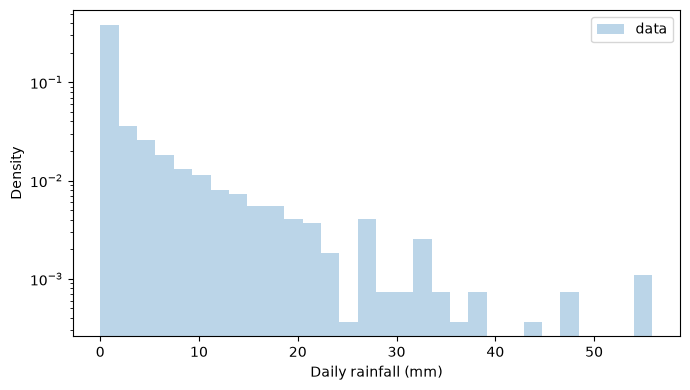

In [3]:
data = pd.read_csv('seattle-weather.xls')
rain = data["precipitation"].dropna()
print("number of samples = ",rain.size)

# plot an histogram of the dataset 
plt.figure(figsize=(7,4))
plt.hist(rain, bins=30, density=True, alpha=0.3, label="data")
plt.yscale('log')
plt.xlabel("Daily rainfall (mm)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

Realize the following tasks:
  1. In order to focus only on the rainfall, what should you do to the dataset ?
  2. Compute the mean of precipitation and its variance.
  3. We want to modelize the data by a Gamma distribution. Using the method of moments, compute an estimate of the Gamma distribution's parameters that fits the data.
  4. In order to get an estimate of the error commited on the parameters, perform a bootstrap using a realization of $n=10000$ Gamma distributed number to estimate the mean and the variance of the estimator.
  5. Give a confidence interval of 95% for the estimation of the parameters.

### Task 1
<span style="color:green">***ACABADA***</span>

In order to focus only on the rainfall, we should drop the rest of the columns of the dataset. We should also verify if there are any NaN (*Not a Number*) values. If so, we would impute the missing values. However, we see there are no such values in the precipitation column.


In [4]:
rain = data["precipitation"]
print(f"There are {int(rain.isna().sum())} missing values")

There are 0 missing values


### Task 2

<span style="color:green">***ACABADA***</span>

Since rain is a pandas Series object (easy to check with ```type(rain)```), then we can use the built-in methods for this class.
**Note:** The returned values of this methods are of type ```np.float64``` (again, easy to check).

There are two methods that can be usefull:

1. ```.mean()```: Computes the sample mean (not population mean). This is the unbiased estimator $\bar{X_n} = \frac{1}{n}\sum_{i=1}^n X_i$ for the population mean.
2. ```.var()```: Computes the sample variance (not the population variance). Sample variance is the unbiased estimator $s_c^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X_n})^2$.

We may think of our data as a sample of the ***random variable given by the weather on seattle at any time***. Thus, we can compute the mean of the precipitacion data as a realization of the mean estimator, and the same with the variance. 

We will also take into account the (biased) estimator for the variance

$$
s^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \bar{X})^2 = \hat{\mu_2} - \hat{\mu_1}^2.
$$

because this will allow us to write the estimators computed with the moments method in convenient terms. In pandas, this is just ```.var(ddof=0)```.

In [5]:
rain_mean = rain.mean() 
biased_rain_var = rain.var(ddof=0)
unbiased_rain_var = rain.var(ddof=1)

print(f"The estimated mean of the precipitation is: {rain_mean}.")
print(f"The estimated (biased) variance of the precipitation is: {biased_rain_var}.")
print(f"The estimated (unbiased) variance of the precipitation is: {unbiased_rain_var}")

The estimated mean of the precipitation is: 3.02943189596167.
The estimated (biased) variance of the precipitation is: 44.5944520386541.
The estimated (unbiased) variance of the precipitation is: 44.624996183886054


### Task 3

<span style="color:green">***ACABADA***</span>

Recall the the Gamma distribution has a probability density function (PDF) given by:

$$
p(x) = x^{\alpha - 1} \frac{\lambda^\alpha \mathrm{e}^{-\lambda x}}{\Gamma(\alpha)}; x \in [0, \infty),
$$

therefore, it has only two parameters: $\alpha$ and $\lambda$. (Note: There are other equivalent forms of the Gamma distribution, and other naming conventions for the parameters; at least according to [Wikipedia](https://en.wikipedia.org/wiki/Gamma_distribution)).

Let $\mu_1$ and $\mu_2$ be the moments of the sample. Since we know from class the moments of the Gamma distribution, $\Gamma(\alpha, \lambda)$, we have that:

$$
\begin{align*}
\mu_1 = \mathbb{E}[X] &= \frac{\alpha}{\lambda}, \hspace{0.5cm}
\mu_2 = \mathbb{E}[X^2] = \frac{\alpha(\alpha + 1)}{\lambda^2},
\end{align*}
$$

so we want to solve the following system on $\nu$ and $\lambda$:

$$
\begin{cases}
\alpha = \lambda\mu_1\\
\alpha^2+\alpha=\lambda^2\mu_2
\end{cases}
$$

By substracting the second ecuation to the first one, if follows easilly that the solution is given by the estimators:

$$
\begin{align*}
\hat{\lambda} &= \frac{\hat{\mu_1}}{\hat{\mu_2} - \hat{\mu_1^2}},\\
\hat{\alpha} &= \frac{\hat{\mu_1^2}}{\hat{\mu_2} - \hat{\mu_1^2}}.
\end{align*}
$$

But $\hat{\mu_1}=\bar{X_n}$ and $\hat{\mu_2} - \hat{\mu_1^2} = s^2$. So we have the estimators:
$$
\begin{align*}
\hat{\lambda} &= \frac{\bar{X_n}}{s^2},\\
\hat{\alpha} &= \frac{\bar{X_n}^2}{s^2}.
\end{align*}
$$
To compute $\hat{\mu_1}$ and $\hat{\mu_2}$ in pandas we use the mean and variance computed in the previous task.

The estimated value of λ through the moments method is 0.06793293240459113.
The estimated value of α through the moments method is 0.20579819221267648.


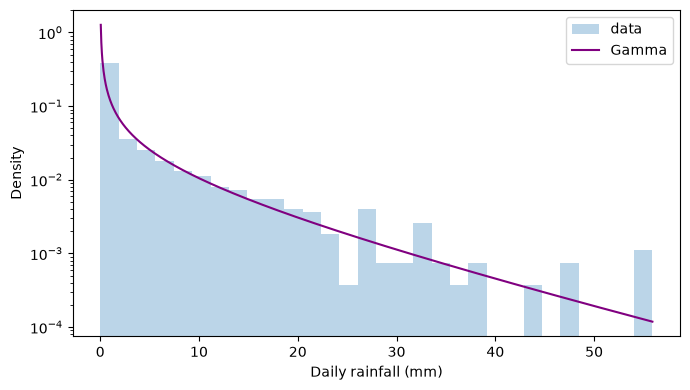

In [6]:
pop_lambda = rain_mean/biased_rain_var
pop_alpha = (rain_mean**2)/biased_rain_var

print(f"The estimated value of λ through the moments method is {pop_lambda}.")
print(f"The estimated value of α through the moments method is {pop_alpha}.")

# Let's plot the Gamma distribution with these parameters (over the histogram) 
# to see how well it fits the empirical distribution
plt.figure(figsize=(7,4))
plt.hist(rain, bins=30, density=True, alpha=0.3, label="data")

x_gamma = np.linspace(0, rain.max(), 1000)
p_x_gamma = gamma.pdf(x_gamma, a=pop_alpha, scale=1/pop_lambda) # Scipy uses another representation of the gamma function...
plt.plot(x_gamma, p_x_gamma, label="Gamma", color="purple")

plt.yscale('log')
plt.xlabel("Daily rainfall (mm)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.show()

### Task 4  

<span style="color:green">***ACABADA***</span>

We now suppose that our population $X$, that is, the precipitations on a given day in seattle, follows a $\Gamma (\hat{\alpha}, \hat{\lambda})$ distribution. We then perform a bootstrap: for each trial, we generate a sample of size $n$ from this Gamma distribution and re-estimate $\alpha$ and $\lambda$. This experiment is repeated $n_{\text{trials}}$ times, where $n_{\text{trials}}$ is chosen as a simulation parameter (not given by the task).

This approach exploits the fact that the estimators $\hat{\lambda}$ and $\hat{\alpha}$ are *random variables*, since they are functions of the random sample. By repeatedly generating samples and computing the corresponding estimates, the bootstrap approximates their sampling distributions. In particular, the empirical variances of the bootstrap estimates provide estimates of the variances of the estimators, and hence their standard deviations provide an estimate of the uncertainty associated with estimating the parameters from a sample of size $n$.

We will discuss further this notion of uncertainty in the next task, when dealing with confidence intervals.

Original estimate of λ: 0.067933
Bootstrap mean of λ estimator: 0.068080
Bootstrap variance of λ estimator: 7.449853e-06

Original estimate of α: 0.205798
Bootstrap mean of α estimator: 0.206168
Bootstrap variance of α estimator: 4.809567e-05


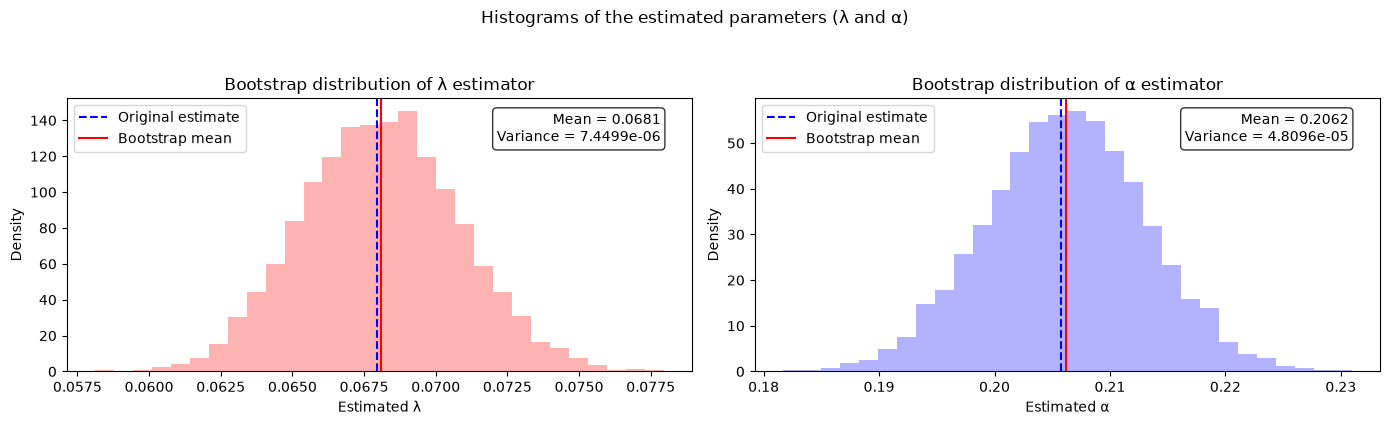

In [7]:
n = 10_000       # Size of each bootstrap sample
n_trials = 8_000 # Number of bootstrap replications (we fix this number since it is not given)

sample_lambdas = np.empty(n_trials)
sample_alphas = np.empty(n_trials)

for i in range(n_trials):
    # Generate one sample directly from the fitted Gamma distribution
    sample = rng.gamma(shape=pop_alpha, scale=1 / pop_lambda, size=n)

    # Apply the same method-of-moments estimators as for the original data (we use s^2, not s_c^2)
    sample_mean = sample.mean()
    sample_var = sample.var(ddof=0)

    sample_lambdas[i] = sample_mean / sample_var
    sample_alphas[i] = sample_mean**2 / sample_var

# Bootstrap estimates of the mean and variance of the estimators
mean_lambda = sample_lambdas.mean()
var_lambda = sample_lambdas.var(ddof=1)

mean_alpha = sample_alphas.mean()
var_alpha = sample_alphas.var(ddof=1)

print(f"Original estimate of λ: {pop_lambda:.6f}")
print(f"Bootstrap mean of λ estimator: {mean_lambda:.6f}")
print(f"Bootstrap variance of λ estimator: {var_lambda:.6e}")
print()

print(f"Original estimate of α: {pop_alpha:.6f}")
print(f"Bootstrap mean of α estimator: {mean_alpha:.6f}")
print(f"Bootstrap variance of α estimator: {var_alpha:.6e}")

# =================================================== #
# Histograms of the bootstrap distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_lambdas,bins=30,density=True,alpha=0.3,color="red")
axes[0].axvline(pop_lambda,color="blue",linestyle="--",label="Original estimate")
axes[0].axvline(mean_lambda,color="red",label="Bootstrap mean")
axes[0].text(
    0.95, 0.95,
    f"Mean = {mean_lambda:.4f}\nVariance = {var_lambda:.4e}",
    transform=axes[0].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[0].set_title("Bootstrap distribution of λ estimator")
axes[0].set_xlabel("Estimated λ")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(sample_alphas,bins=30,density=True,alpha=0.3,color="blue")
axes[1].axvline(pop_alpha,color="blue",linestyle="--",label="Original estimate")
axes[1].axvline(mean_alpha,color="red",label="Bootstrap mean")
axes[1].text(
    0.95, 0.95,
    f"Mean = {mean_alpha:.4f}\nVariance = {var_alpha:.4e}",
    transform=axes[1].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[1].set_title("Bootstrap distribution of α estimator")
axes[1].set_xlabel("Estimated α")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle('Histograms of the estimated parameters (λ and α)', y=1.05)

plt.tight_layout()
plt.show()

### Task 5

<span style="color:green">***ACABADA***</span>

Deriving a formal confidence interval would be complicated because the usual pivotal quantities would depend on both parameters, as the mean and the variance of the Gamma distribution depend on $\alpha$ and $\lambda$. We might approximate these intervals using the information obtained in Task 4.

Using the bootstrap method, we constructed empirical distributions for the parameter estimators from a large number of simulated samples. We observed that the shapes of these distributions are remarkably similar to those of normal distributions. However, we do not know of any asymptotic theorem that can be directly applied to the estimators used, and assuming normality would require further justification.

Therefore, we are going to be cautious and compute empirical intervals from the bootstrap estimates. That is, we are going to use the quantiles $q_{0.025}$ and $q_{0.975}$ of each distribution. Note that 95% of the bootstrap estimates lie between these two values.

In [8]:
alpha_ci = 0.05

In [9]:
lambda_low  = np.quantile(sample_lambdas, alpha_ci/2)
lambda_high = np.quantile(sample_lambdas, 1-(alpha_ci/2))

alpha_low  = np.quantile(sample_alphas, alpha_ci/2)
alpha_high = np.quantile(sample_alphas, 1-(alpha_ci/2))

print(f"The 95% bootstrap confidence interval for λ is: "
      f"[{lambda_low}, {lambda_high}]"
)

print(f"The 95% bootstrap confidence interval for α is: "
      f"[{alpha_low}, {alpha_high}]"
)

The 95% bootstrap confidence interval for λ is: [0.06289075238953944, 0.07350407290412722]
The 95% bootstrap confidence interval for α is: [0.19265164165857898, 0.2195516553792766]


## Bayesian Inference Analysis

We now proceed to a Bayesian inference analysis:
  1. Find an implicit expression to find the parameters $\lambda$ and $\nu$ of the Gamma distribution using the Maximum likelihood approach. 
  2. Solve these equations and compare their value to the method of moments.
  3. Let's assume that we fix $\lambda$ to the value obtained in the method of moments. Using a uniform prior for $\nu \in [0,20]$, compute and plot the posterior distribution of $\nu$.

### Task 1

<span style="color:green">***ACABADA***</span>

Let's start by formulating the log-likelihood function for $n$ samples. Notice that we use the log-likelihood because it's simpler to work with and induces less numerical errors. The log-likelihood function is then:

$$
\begin{align*}
\ell(\nu, \lambda) &= \frac{1}{n}\sum_{i=1}^n \log p(x_i \lvert \nu, \lambda)\\
&= \frac{1}{n}\sum_{i=1}^n \log \left(x_i^{\nu - 1} \frac{\lambda^\nu \mathrm{e}^{-\lambda x_i}}{\Gamma(\nu)} \right)\\
&= \frac{1}{n}\sum_{i=1}^n \Bigg[ \log(x_i^{\nu - 1}) + \log \left(\frac{\lambda^\nu \mathrm{e}^{-\lambda x_i}}{\Gamma(\nu)} \right) \Bigg]\\
&= \frac{1}{n}\sum_{i=1}^n \Bigg[ (\nu - 1)\log(x_i) + \nu \log(\lambda) - \lambda x_i - \log\big(\Gamma(\nu)\big) \Bigg]\\
&= \Bigg(\frac{(\nu - 1)}{n}\sum_{i=1}^n \log(x_i)\Bigg) + \nu \log(\lambda) - \lambda \hat{\mu} - \log\big(\Gamma(\nu)\big),
\end{align*}
$$

then, defining $\gamma_n = \frac{1}{n}\sum_{i=1}^n \log(x_i)$, we have:

$$
\ell(\nu, \lambda) = (\nu - 1)\gamma_n + \nu \log(\lambda) - \lambda \hat{\mu} - \log\big(\Gamma(\nu)\big)
$$

Now let's differentiate with respect to $\lambda$ and $\mu$:

$$
\begin{align*}
\frac{\partial}{\partial \nu} \ell &= \gamma_n + \log(\gamma) - \frac{\Gamma'(\nu)}{\Gamma(\nu)}\\
\frac{\partial}{\partial \lambda} \ell &= \frac{\nu}{\lambda} - \hat{\mu},
\end{align*}
$$

where in the first equality we used the fact that $\partial\nu \log(\Gamma(\nu)) = \psi(\nu) = \frac{\Gamma'(\nu)}{\Gamma(\nu)}$ (the *digamma* function).

With all of this, we have that the formulation of our problem is

$$
(\hat{\lambda}_{MLE}, \hat{\nu}_{MLE}) = \argmax_{\lambda, \nu > 0} \ell(\nu, \lambda)
$$

and it can be solved using some gradient ascent method (there are, of course, other posibilities, but we'll try to minimize the manual job as much as possible).

One last thing we should check is that the problem is well posed. That is, that it has a unique solution. To do this, we'll check (visually) that the function is concave and it posses a single maxima.

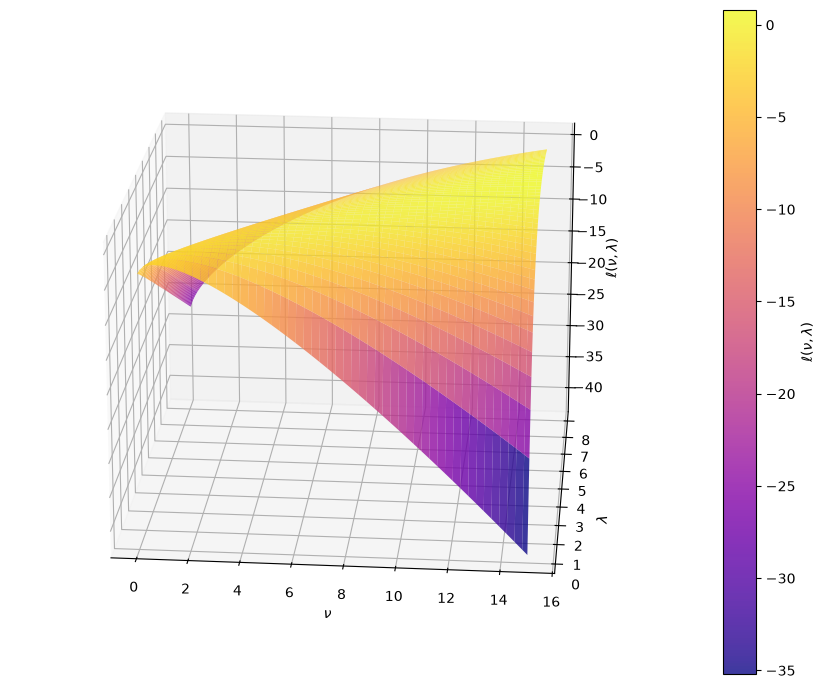

In [10]:
# Let's stick with only the positive values. Otherwise, we won't be able to compute gamma_n
rain_pos = rain[rain > 0]

# Computation of the constants
gamma_n = np.mean(np.log(rain_pos))
mu_hat = np.mean(rain_pos) # No need really... 
                           # The 0-values we are excluding does not affect the pre-computated mean.
                           # We leave it here for readability :)

# Range of values where we'll plot the log-likelihood
nu = np.linspace(0.1, 15, 150)
lam = np.linspace(0.1, 8, 150)

NU, LAM = np.meshgrid(nu, lam)

# Value of the log-likelihood on the (nu x lam) rectangle
L = (
    (NU - 1) * gamma_n
    + NU * np.log(LAM)
    - LAM * rain_mean
    - gammaln(NU)
)

# 3D Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(NU, LAM, L, alpha=0.80, cmap="plasma")
ax.view_init(elev=20, azim=275) # View angle
fig.colorbar(surf, ax=ax, label=r"$\ell(\nu,\lambda)$") # Color label

ax.set_xlabel(r"$\nu$")
ax.set_ylabel(r"$\lambda$")
ax.set_zlabel(r"$\ell(\nu,\lambda)$")

plt.tight_layout()
plt.show()

Then it's clear that the function has a single maxima.

### Task 2

<span style="color:green">***ACABADA***</span>

Since $\ell$ is convex, then $-\ell$ is concave. Therefore, we can apply any classic minimizing method over $-\ell$. Scipy has a lot of them inside the function ```minimize()```. We'll let it choose automatically, and our job will just be to enforce the bounds of the parameters (strictly positive with no upper bound) and provide functions for evaluating $\ell$ and $\nabla \ell$.

In [11]:
# Log-likelihood evaluation function
def loglik(theta : tuple):
    nu, lam = theta
    ell = (nu - 1) * gamma_n + nu * np.log(lam) - lam * mu_hat - gammaln(nu)
    return ell

# Log-likelihood gradient
def grad_loglik(theta : tuple):
    nu, lam = theta

    d_nu = gamma_n + np.log(lam) - digamma(nu)
    d_lam = nu / lam - mu_hat

    return np.array([d_nu, d_lam])

result = minimize(
    lambda theta : -loglik(theta),
    x0=np.array([pop_alpha, pop_lambda]),      # Initial guess. We can use the lambda and nu from the method of moments
    jac= lambda theta : -grad_loglik(theta),                  
    bounds=[(1e-8, None), (1e-8, None)]        # Bounds. 1e-8 just to assure we are slightly above 0. No upper bound
)

nu_hat_mle, lambda_hat_mle = result.x

print(f"Status of convergence: {result.message}")
print(f"Log-likelihood value on obtained maximum: {grad_loglik(result.x)}")

print("Log-likelihood value on estimators obtained by method of moments:", loglik([pop_alpha, pop_lambda]))
print("Log-likelihood value on estimators obtained by MLE:", loglik([nu_hat_mle, lambda_hat_mle]))

print(f"Method of moments estimate of λ: {pop_lambda:.6f}")
print(f"Method of moments estimate of ν (α): {pop_alpha:.6f}")

print(f"MLE estimate of λ: {lambda_hat_mle:.6f}")
print(f"MLE estimate of ν (α): {nu_hat_mle:.6f}")


Status of convergence: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Log-likelihood value on obtained maximum: [ 5.68764134e-07 -3.96127770e-06]
Log-likelihood value on estimators obtained by method of moments: -3.496224273870502
Log-likelihood value on estimators obtained by MLE: -2.942484136136457
Method of moments estimate of λ: 0.067933
Method of moments estimate of ν (α): 0.205798
MLE estimate of λ: 0.112326
MLE estimate of ν (α): 0.798003


### Task 3

<span style="color:orange">***EN PROCESO***</span>

<span style="color:red">***TODO: Rellenar y hacer código***</span>

## Part II: Mining

We now pass to the study of a different dataset about the number of accidents occurring each year in mines (in UK).

number of points =  (112,)


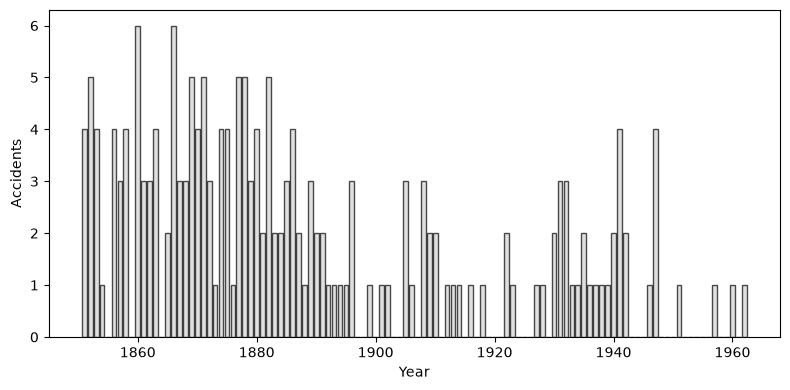

In [12]:

data = pd.read_csv('coal.csv')
X = data['Count'].to_numpy()
print("number of points = ",X.shape)
years = np.arange(1851, 1962+1)

plt.figure(figsize=(8,4))
plt.bar(years, X, color='lightgray', edgecolor='k', alpha=0.7)
plt.xlabel("Year"); plt.ylabel("Accidents")
#plt.legend(); 
plt.tight_layout();

We first consider the modelization of such event by a Poisson distribution 
$$
p(k) = \frac{\lambda^{k}}{k!} \exp(-\lambda)
$$
1. Compute the Fisher Information $I(\lambda) = \mathbb{E}\left[\left(\frac{\partial}{\partial \lambda} \log p_{\lambda}(k)\right)^2 \right]$.
2. Compute the MLE $\hat{\lambda}$ of the parameter $\lambda$ on the data, and give the estimate of the standard error for the estimator.
3. Using the value $\hat{\lambda}$, plot a sequence of $n=112$ random Poisson number and compare it to the data. Do you notice something ?

### Task 1

<span style="color:green">***ACABADA***</span>

Let us compute the Fisher information number:

$$
\begin{align*}
&p_\lambda(k) = \frac{\lambda^{-k}}{k!}\mathrm{e}^{-\lambda}\\
\implies& \log p_\lambda(k) = \log\left(\frac{\lambda^k}{k!}\right) - \lambda = k\log(\lambda) - \log(k!) - \lambda\\
\implies& \frac{\partial}{\partial \lambda} \log p_\lambda(k) = \frac{k}{\lambda} - 1\\
\implies& \left(\frac{\partial}{\partial \lambda} \log p_\lambda(k) \right)^2 = \frac{k^2}{\lambda^2} - \frac{2k}{\lambda} + 1.
\end{align*}
$$

It's kind of *fastidioso* to calculate $\mathbb{E}\left[(\partial_\lambda \log p_\lambda(k))^2\right]$, so we can use what we learned in class:

$$
\mathbb{E}\left[\left(\frac{\partial}{\partial \lambda} \log p_{\lambda}(k)\right)^2 \right] = -\mathbb{E}\left[\frac{\partial^2}{\partial \lambda^2} \log p_{\lambda}(k) \right],
$$

and since

$$
\frac{\partial^2}{\partial \lambda^2} \log p_{\lambda}(k) = -\frac{k}{\lambda^2},
$$

we have:

$$
\begin{align*}
\mathbb{E}\left[\left(\frac{\partial}{\partial \lambda} \log p_{\lambda}(k)\right)^2 \right] &= -\mathbb{E}\left[\frac{\partial^2}{\partial \lambda^2} \log p_{\lambda}(k) \right]\\
&=- \left(-\frac{1}{\lambda^2}\right)\int_\mathbb{R} k p_\lambda(k) dk\\
&= \frac{1}{\lambda^2} \mathbb{E}[X] \text{ (where } X \text{ is a Poisson variable)}\\
&= \lambda^{-2} \lambda\\
&= \lambda^{-1}.
\end{align*}
$$

Therefore, the Fisher information $I(\lambda)$ is

$$
I(\lambda) = \frac{1}{\lambda}
$$

In [13]:
# No code for this task ;)

### Task 2

<span style="color:green">***ACABADA***</span>

We'll perform a similar argument to the one done in the Task 1 of the Bayesian inference section. We have that the MLE estimator for $\lambda$ can be obtained as follows (using the log-likelihood function):

$$
\begin{align*}
\ell(\lambda) &= \frac{1}{n} \sum_{i=1}^n \log p_\lambda(k_i)\\
&= \frac{1}{n} \sum_{i=1}^n \left[k_i \log(\lambda) - \log(k_i!) - \lambda \right]\\
&= \log(\lambda) \left(\frac{1}{n}\sum_{i=1}^2 k_i \right) - \left(\frac{1}{n}\sum_{i=1}^n \log(k_i!)\right) - \lambda\\
&= \log(\lambda) \hat{\mu} - \left(\frac{1}{n}\sum_{i=1}^n \log(k_i!)\right) - \lambda.
\end{align*}
$$

Computing the derivative with respect to $\lambda$ we obtain:

$$
\frac{\partial}{\partial \lambda} \ell(\lambda) = \frac{\hat{\mu}}{\lambda} - 1,
$$

and we have a critical point of $\ell$ if and only if:

$$
\frac{\partial}{\partial \lambda} \ell(\lambda) = \frac{\hat{\mu}}{\lambda} - 1 = 0 \iff \lambda = \hat{\mu}.
$$

Therefore,

$$
\hat{\lambda}_{MLE} = \hat{\mu}.
$$

Let's check if this critical point is a maximum point and, if it is, if it's global. To do this, we check the second derivative of $\ell$:

$$
\frac{\partial^2}{\partial \lambda^2} \ell(\lambda) = -\frac{\hat{\mu}}{\lambda^2}.
$$

Since $\hat{\mu}$ is a strictly positive (assuming that not all the data is 0, which is the case) quantity given the nature of the data, we have that $\frac{\partial^2}{\partial \lambda^2} \ell(\lambda) < 0$ and thus $\lambda = \hat{\mu}$ is a global maxima.

In [14]:
# As we've seen in the Jupyter cell from before, we just need to compute the sample mean to estimate λ
lambda_mle = X.mean()
print(f"λ MLE estimator: {lambda_mle}")

λ MLE estimator: 1.7053571428571428


### Task 3

<span style="color:green">***ACABADA***</span>

When we plot the $n=112$ random Poisson numbers, we can see that the numbers fluctuate randomly around the mean $\hat{\lambda}_{MLE}$, whereas the real exhibits a decreasing temporal trend. 

This makes sense with the data we are working with, because one would expect that accidents decrease as the years passes because of improved safety measures, the automatization of processes, and many more external factors that indirectly affect our data. 

Thus, a Poisson model is inssuficient to capture this trend, and maybe a more suitable distribution would be

$$
Pois(\lambda(t)),
$$

where the mean $\lambda$ depends on the time (years) passed. This, of course, requires more mathematical machinery and is beyond the scope of this notebook.

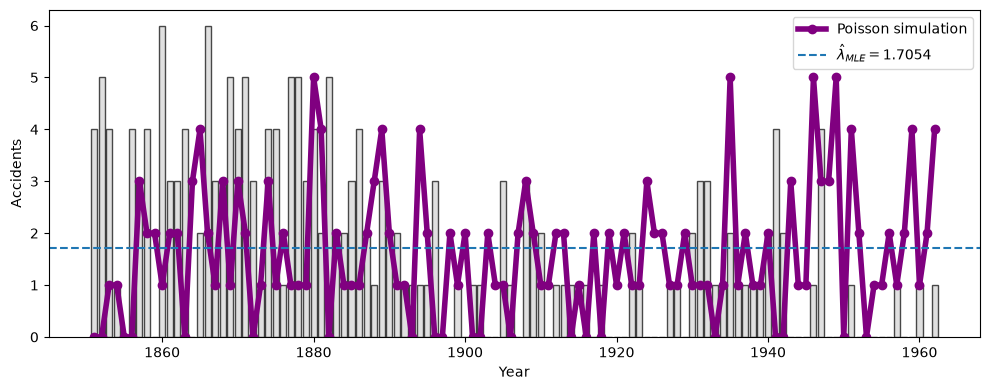

In [15]:
# Generate 112 Poisson observations
Y = rng.poisson(lam=lambda_mle, size=112)

# =================================================== #
plt.figure(figsize=(10, 4))

# Plot original data
plt.bar(years, X, color='lightgray', edgecolor='k', alpha=0.7)
plt.xlabel("Year"); plt.ylabel("Accidents")

# Plot the 112 Poisson observations
plt.plot(years, Y, 'o-', color='purple', linewidth=4, markersize=6, label='Poisson simulation')

# Plot horizontal line on the lambda MLE estimator (which is the expected value of a Poisson random variable)
plt.axhline(lambda_mle, linestyle='--', label=fr'$\hat{{\lambda}}_{{MLE}}={lambda_mle:.4f}$')

plt.xlabel("Year")
plt.ylabel("Accidents")
plt.legend()
plt.tight_layout()
plt.show()

## Ceasure in the series

There seems to be a ceasure in the series at some point. We will try to modelize it using a Poisson distribution where the parameter $\lambda(t)$ will depend on the time we consider:
$$
\lambda(t) = \left\{ \begin{array}{c} \lambda_1 \text{ if } t<t_* \\ \lambda_2 \text{ if } t>t_*  \end{array}\right.
$$
We now will use only the likelihood of the model. In order to find the best value of $t_*$, 
1. Make list (numpy array) of all possible values of $t_*$
2. For each possible value of $t_*$, first compute the estimate of $(\lambda_1,\lambda_2)$ and compute the value of the likelihood.
3. Then select the value of $t_*$ that maximizes the likelihood.
4. Fixing the estimate of $(\hat{\lambda_1},\hat{\lambda_2})$, ans assuming that a prior $p(t_*)$ is uniform in the range $I_t = [1880,1920]$, make a graphics of the distribution $p(t_*|X)$

### Task 1

<span style="color:green">***ACABADA***</span>

We are going to consider
$$
\lambda(t) = \left\{ \begin{array}{c} \lambda_1 \text{ if } t\leq t_* \\ \lambda_2 \text{ if } t>t_*  \end{array}\right.
$$
so the value $t_*$ is not left out.

In [16]:
times = data['Year'].to_numpy()

### Task 2

<span style="color:green">***ACABADA***</span>

The restriction ${t\leq t_*}$ divides the array "times" in two: the ones that satisfies it, and the ones that not. Lets consider the log-likelihood in this terms:

$$ \ell(\lambda_1,\lambda_2;t_*) = \sum_{i=1}^{n}\log f\left(x_i;\lambda(t_i)\right) = \sum_{\{i:t_i\leq t_*\}} \log f(x_i;\lambda_1) + \sum_{\{i:t_i>t_*\}} \log f(x_i;\lambda_2). 
$$

This is 
$$
\ell(\lambda_1, \lambda_2) = \sum_{\{t\leq t_*\}} x_i \text{log}(\lambda_1) - n_1\lambda_1 + \sum_{\{t> t_*\}} x_i \text{log}(\lambda_2) - n_2\lambda_2 - \text{log}(\prod_{i=1}^n xi!)
$$

We can compute the partial derivative:

$$ \frac{\partial\ell}{\partial\lambda_1} = \frac{1}{\lambda_1} \sum_{\{i:t_i\leq t_*\}}x_i -n_1. $$ Setting this derivative equal to zero gives $$ \frac{1}{\widehat{\lambda}_1} \sum_{\{i:t_i\leq t_*\}}x_i -n_1 =0, $$ and therefore $$ \widehat{\lambda}_1(t_*) = \frac{1}{n_1} \sum_{\{i:t_i\leq t_*\}}x_i. $$


We can do the same whit $\lambda_2$ and obtain the critic point $(\hat{\lambda}_{1}(t_*), \hat{\lambda}_{2}(t_*))$ given by: $$\hat{\lambda}_{1}(t_*)=\frac{1}{n_1}{\sum_{\{t\leq t_*\}}}x_i, \hspace{0.5cm} \hat{\lambda}_{2}(t_*)=\frac{1}{n_2}{\sum_{\{t> t_*\}}}x_i$$

It is easy to check that the second order derivatives provide the next hessian matrix: 
$$
\text{Hess}(\ell) = \begin{pmatrix} \frac{-\sum_{\{t\leq t_*\}}x_i}{\lambda_1^2} & 0 \\ 0 & \frac{-\sum_{\{t> t_*\}}x_i}{\lambda_2^2} \end{pmatrix}.
$$

And since the sum of "number of accidents" is not negative, this is a positive definite matrix for every value of $\lambda_1, \lambda_2$. Thus, the function $\ell$ is concave, and so the global maximum is reached at the computed critic point.

We are going to compute the realizations of this estimators and their values on $\ell$ for each $t_*$.

In [17]:
# We will use the gamma funtion to compute the factorials
# Allthough is not needed to find the maximum, we will compute the sum(log(x_i!)) in order to have the real values of l.

results = {}
# Exclude the final year so both subsets contain at least one observation.
for t in times[:-1]:
    
    X_1 = data.loc[data["Year"] <= t, "Count"].to_numpy()
    X_2 = data.loc[data["Year"] > t, "Count"].to_numpy()

    n1 = X_1.size
    n2 = X_2.size

    lambda_1 = X_1.mean()
    lambda_2 = X_2.mean()

    l_1 = X_1.sum() * np.log(lambda_1) - n1 * lambda_1
    l_2 = X_2.sum() * np.log(lambda_2) - n2 * lambda_2

    # -log(product(x_i!)) = -sum(log(x_i!))
    factorial_term = (
        gammaln(X_1 + 1).sum()
        + gammaln(X_2 + 1).sum()
    )

    log_likelihood = l_1 + l_2 - factorial_term

    # We build the dictionary to find the value t_* asociated to the biggest l value.
    results[t] = {
        "lambda_1": lambda_1,
        "lambda_2": lambda_2,
        "log_likelihood": log_likelihood
    }

### Task 3

<span style="color:green">***ACABADA***</span>

We'll select the value of $t_*$ that maximizes the likelihood.

In [18]:
t_star = max(results, key=lambda t: results[t]["log_likelihood"])
best_result = results[t_star]

lambda_1 = best_result['lambda_1']
lambda_2 = best_result['lambda_2']

print(f"Estimated change point: t_* = {t_star}")
print(f"Estimated lambda_1: {lambda_1}")
print(f"Estimated lambda_2: {lambda_2}")
print(f"Maximum log-likelihood: {best_result['log_likelihood']}")
print(f"Maximum likelihood: {np.exp(best_result['log_likelihood'])}")

Estimated change point: t_* = 1891
Estimated lambda_1: 3.097560975609756
Estimated lambda_2: 0.9014084507042254
Maximum log-likelihood: -168.86367922875104
Maximum likelihood: 4.607187816727289e-74


Aditionally, we plot the values of the log-likelihood:

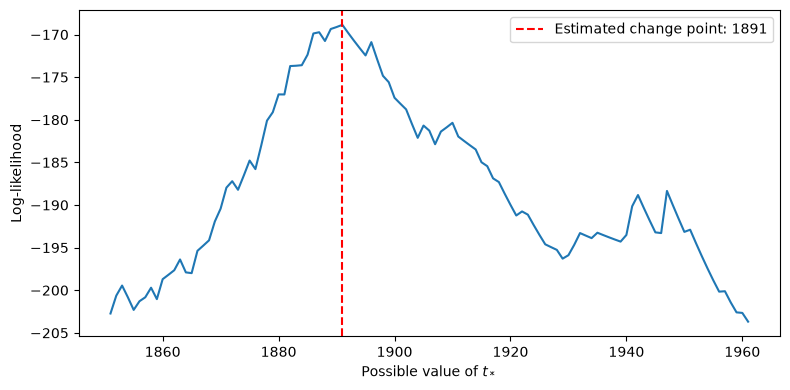

In [19]:
plt.figure(figsize=(8, 4))

plt.plot(
    list(results.keys()),
    [result["log_likelihood"] for result in results.values()]
)

plt.axvline(
    t_star,
    color="red",
    linestyle="--",
    label=f"Estimated change point: {t_star}"
)

plt.xlabel("Possible value of $t_*$")
plt.ylabel("Log-likelihood")
plt.legend()
plt.tight_layout()
plt.show()

### Task 4

<span style="color:green">***ACABADA***</span>

We want to compute 
$$p(t_*|X)= \frac{p(X|t_*)p(t_*)}{p(X)}$$

On one hand, since we can supose $t_*$ uniformlly distributed in $\set{1880,1881,...,1920}$, and this set has $41$ elementes, we have $p(t_*)=1/41$. On the other hand, we can do 

$$
p(X)=\sum_{t=1880}^{1920}p(X\cap \set{t_*=t})=\sum_{t=1880}^{1920}p(X|t_*=t)p(t_*)=\frac{1}{41}\sum_{t=1880}^{1920}p(X|t_*=t)
$$

So we get 
$$p(t_*|X)= \frac{p(X|t_*)}{\sum_{t=1880}^{1920}p(X|t_*=t)}$$

We can compute $p(X|t_*)$ if we suppose that the number of accidents are independet between years:
$$p(X|t_*)=p(X_1=x_1,...,X_n=x_n |t_*)\overset{\mathrm{ind.}}{=}\prod_{i=1}^n p(X_i=x_i|t_*)=\prod_{\{i:t_i\leq t_*\}} \frac{\lambda_1^{x_i}e^{-\lambda_1}}{x_i!} \prod_{\{i:t_i>t_*\}} \frac{\lambda_2^{x_i}e^{-\lambda_2}}{x_i!}.$$

Now we plot the resulting function of t_*. We will use as posible inputs the years between 1880 and 1920 (in our hypothesis, every other date has $p(t_\ast)=0$).

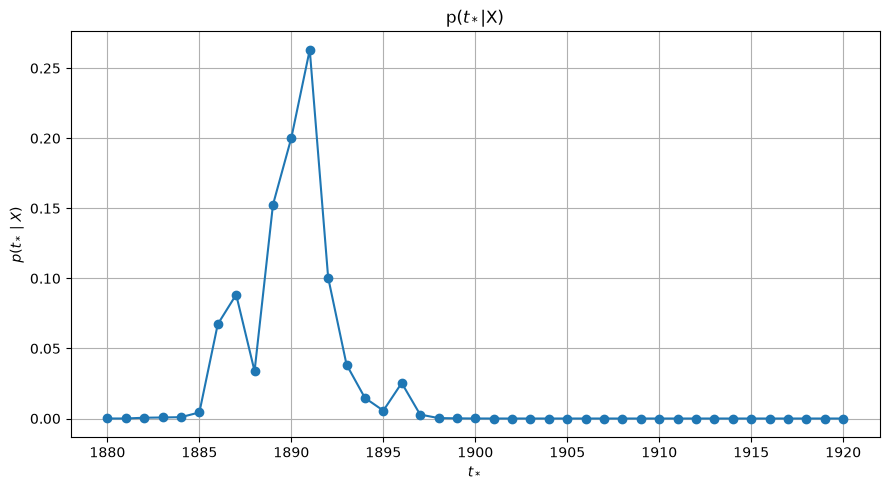

In [20]:
t_candidates = np.arange(1880, 1921)
likelihoods = []

for t_star in t_candidates:
    X_1 = data.loc[data["Year"] <= t_star, "Count"].to_numpy()
    X_2 = data.loc[data["Year"] > t_star, "Count"].to_numpy()

    p_X_1 = poisson.pmf(X_1, mu=lambda_1).prod()
    p_X_2 = poisson.pmf(X_2, mu=lambda_2).prod()

    p_X_given_t = p_X_1 * p_X_2
    likelihoods.append(p_X_given_t)

likelihoods = np.array(likelihoods)

posterior = likelihoods / likelihoods.sum()

plt.figure(figsize=(9, 5))
plt.plot(t_candidates, posterior, marker="o")

plt.xlabel(r"$t_*$")
plt.ylabel(r"$p(t_*\mid X)$")
plt.title(r"p($t_*$|X)")
plt.grid()
plt.tight_layout()
plt.show()